In [1]:
pip install xgboost

🔍 Training Binary XGBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

📊 Classification Report (Binary):
                precision    recall  f1-score   support

No Interaction       0.93      0.93      0.93      2211
   Interaction       0.94      0.94      0.94      2405

      accuracy                           0.93      4616
     macro avg       0.93      0.93      0.93      4616
  weighted avg       0.93      0.93      0.93      4616



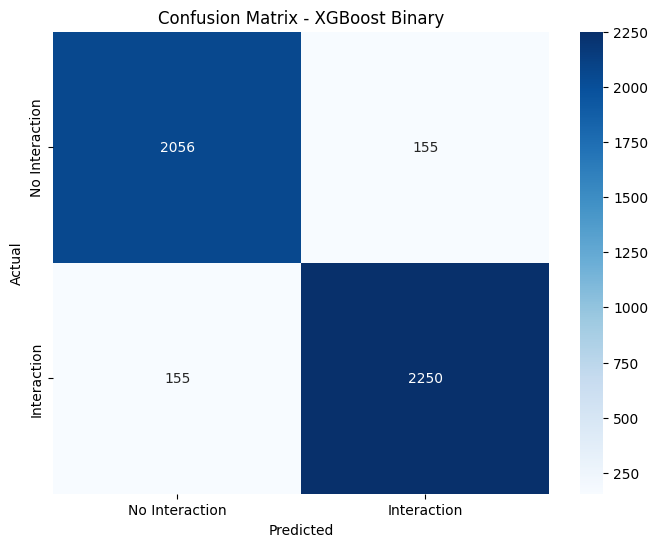

In [3]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ====================== LOAD DATA ======================
df = pd.read_csv('DDinter_with_negatives.csv')

df['Drug_A'] = df['Drug_A'].str.lower().str.strip()
df['Drug_B'] = df['Drug_B'].str.lower().str.strip()

# ====================== BINARY TARGET ======================
df['Level_binary'] = df['Level'].apply(
    lambda x: 0 if str(x).strip().lower() in ['none', 'no interaction', '0'] else 1
)

# ====================== CLEAN ======================
df = df.dropna(subset=['Drug_A', 'Drug_B', 'Level_binary'])
df = df.drop_duplicates()

X = df[['Drug_A', 'Drug_B']]
y = df['Level_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ====================== PIPELINE ======================
pipeline = Pipeline([
    ('encoder', TargetEncoder(target_type='binary')),
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# ====================== PARAM SEARCH ======================
param_dist = {
    'xgb__n_estimators': [200, 400, 600],
    'xgb__max_depth': [4, 6, 8],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.7, 0.8, 1.0],
    'xgb__colsample_bytree': [0.7, 0.8, 1.0],
    'xgb__gamma': [0, 1, 5]
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("🔍 Training Binary XGBoost...")
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

# ====================== EVALUATION ======================
y_pred = best_model.predict(X_test)

print("\n📊 Classification Report (Binary):")
print(classification_report(
    y_test, y_pred,
    target_names=['No Interaction', 'Interaction']
))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Interaction', 'Interaction'],
            yticklabels=['No Interaction', 'Interaction'])
plt.title("Confusion Matrix - XGBoost Binary")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [5]:
# ====================== SAVE MODEL ======================
import joblib

joblib.dump(best_model, 'ddi_binary_xgb_model.pkl')
print("\n✅ Model saved as 'ddi_binary_xgb_model.pkl'")


✅ Model saved as 'ddi_binary_xgb_model.pkl'


In [6]:
# ====================== ADDITIONAL METRICS ======================
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")


✅ Accuracy: 0.9328 (93.28%)


In [7]:
# ====================== OVERALL METRICS (Binary - Balanced) ======================
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Overall metrics for binary classification (Interaction = positive class)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary', pos_label=1)
recall    = recall_score(y_test, y_pred, average='binary', pos_label=1)
f1        = f1_score(y_test, y_pred, average='binary', pos_label=1)

print("\n" + "="*55)
print("📊 OVERALL METRICS (Binary Classification)")
print("="*55)
print(f"Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("="*55)


📊 OVERALL METRICS (Binary Classification)
Accuracy  : 0.9328  (93.28%)
Precision : 0.9356
Recall    : 0.9356
F1-Score  : 0.9356
